In [317]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [128]:
dataset = baseClasses.Data()

In [136]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 5, 13)) & (dataset.data.index < datetime.datetime(2024, 5, 20)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

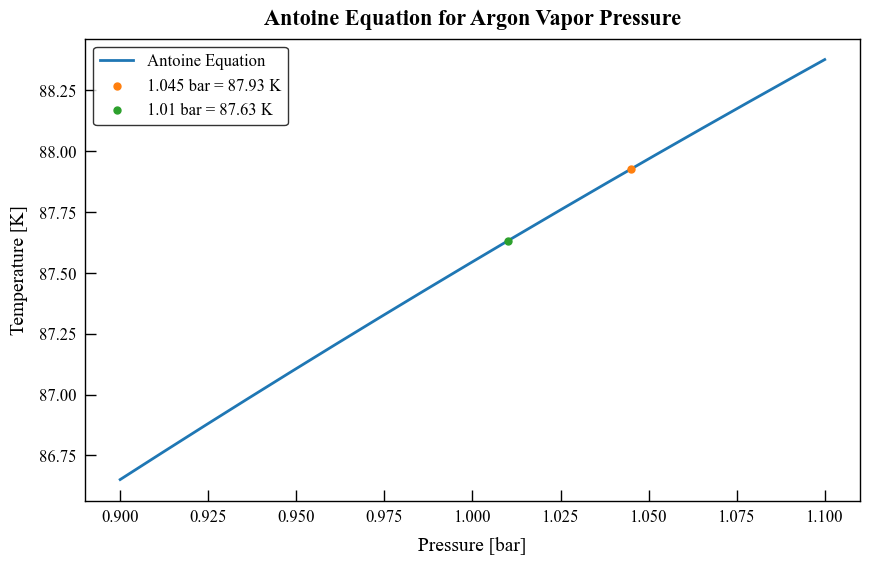

In [318]:
import numpy as np

# Antoine constants (pressure in bar, temperature in Kelvin)
A = 3.29555
B = 215.24
C = -22.233

def antoine_temperature_bar(P_bar):
    """
    Compute temperature (K) from vapor pressure (bar) for argon using corrected Antoine parameters.

    https://webbook.nist.gov/cgi/cbook.cgi?ID=C7440371&Mask=4&Type=ANTOINE&Plot=on#ANTOINE

    Parameters:
        P_bar (float or array-like): Vapor pressure in bar

    Returns:
        T (float or array-like): Temperature in Kelvin
    """
    log10_P = np.log10(P_bar)
    T = B / (A - log10_P) - C
    return T

# Example usage
P = np.linspace(0.9, 1.1, 300)  # bar
T = antoine_temperature_bar(P)

p1 = 1.045
T1 = antoine_temperature_bar(p1)

p2 = 1.01
T2 = antoine_temperature_bar(p2)

fig, axes = plt.subplots(figsize=(10, 6))
axes.plot(P, T, label="Antoine Equation", color="tab:blue")
axes.scatter([p1], [T1], marker="o", color="tab:orange", label=f"{p1} bar = {T1:.2f} K", zorder=5)
axes.scatter([p2], [T2], marker="o", color="tab:green", label=f"{p2} bar = {T2:.2f} K", zorder=5)
axes.set_xlabel("Pressure [bar]")
axes.set_ylabel("Temperature [K]")
axes.set_title("Antoine Equation for Argon Vapor Pressure")
axes.legend()

In [382]:


tgrad = systemClasses.System(dataset=dataset, name="TGRAD")
hawai = systemClasses.System(dataset=dataset, name="HAWAI")
pipe = systemClasses.System(dataset=dataset, name="PIPE")
apa = systemClasses.System(dataset=dataset, name="APA")
pump = systemClasses.System(dataset=dataset, name="PP")
prm = systemClasses.System(dataset=dataset, name="PRM")
ga1 = systemClasses.System(dataset=dataset, name="GA-1")
ga2 = systemClasses.System(dataset=dataset, name="GA-2")
wall = systemClasses.System(dataset=dataset, name="WALL")
floor = systemClasses.System(dataset=dataset, name="FLOOR")

Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00, 10.99sensor/s]


ERROR: Channel (TE0120) not found


Initializing FLOOR Sensors: 100%|██████████| 12/12 [00:01<00:00, 11.43sensor/s]


In [383]:
tgrad.calibrate(calibName="FIRST_POFF_PIPES")
apa.calibrate(calibName="FIRST_POFF_PIPES")
pump.calibrate(calibName="FIRST_POFF_PIPES")
prm.calibrate(calibName="FIRST_POFF_PIPES")
hawai.calibrate(calibName="FIRST_POFF_PRECISION")
pipe.calibrate(calibName="FIRST_POFF_PIPES")
wall.calibrate(calibName="FIRST_POFF_PIPES")
# ga1.calibrate(calibName="FIRST_POFF_PIPES")
# ga2.calibrate(calibName="FIRST_POFF_PIPES")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:05<00:00,  8.14sensor/s]
Calibrating TGRAD Sensors - Calibration Name: FIRST_POFF_PIPES: 100%|██████████| 48/48 [00:00<00:00, 80.45sensor/s]
Equalizing APA Sensors: 100%|██████████| 16/16 [00:01<00:00, 11.43sensor/s]
Calibrating APA Sensors - Calibration Name: FIRST_POFF_PIPES: 100%|██████████| 16/16 [00:00<00:00, 74.26sensor/s]
Equalizing PP Sensors: 100%|██████████| 2/2 [00:00<00:00,  8.49sensor/s]
Calibrating PP Sensors - Calibration Name: FIRST_POFF_PIPES: 100%|██████████| 2/2 [00:00<00:00, 70.10sensor/s]
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:00<00:00,  7.49sensor/s]
Calibrating PRM Sensors - Calibration Name: FIRST_POFF_PIPES: 100%|██████████| 6/6 [00:00<00:00, 72.75sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:02<00:00,  8.09sensor/s]
Calibrating HAWAI Sensors - Calibration Name: FIRST_POFF_PRECISION: 100%|██████████| 24/24 [00:00<00:00, 95.96sensor/s]
Equalizing PIPE Sensors: 100%|██████████| 12/12 

ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: FIRST_POFF_PIPES: 100%|██████████| 12/12 [00:00<00:00, 99.02sensor/s]
Equalizing WALL Sensors: 100%|██████████| 5/5 [00:00<00:00, 10.53sensor/s]
Calibrating WALL Sensors - Calibration Name: FIRST_POFF_PIPES: 100%|██████████| 5/5 [00:00<00:00, 98.89sensor/s]

ERROR: SensorID (40066) not found in calibration (FIRST_POFF_PIPES)
ERROR: SensorID (40067) not found in calibration (FIRST_POFF_PIPES)
ERROR: SensorID (40068) not found in calibration (FIRST_POFF_PIPES)
ERROR: SensorID (40069) not found in calibration (FIRST_POFF_PIPES)
ERROR: SensorID (40070) not found in calibration (FIRST_POFF_PIPES)


In [384]:
tgrad.calibrate(calibName="SECOND_POFF_EMPTY")
apa.calibrate(calibName="SECOND_POFF_OCTOBER")
pump.calibrate(calibName="SECOND_POFF_OCTOBER")
prm.calibrate(calibName="SECOND_POFF_OCTOBER")
hawai.calibrate(calibName="SECOND_POFF_EMPTY")
pipe.calibrate(calibName="SECOND_POFF_OCTOBER")
wall.calibrate(calibName="SECOND_POFF_OCTOBER")
# ga1.calibrate(calibName="FIRST_POFF_PIPES")
# ga2.calibrate(calibName="FIRST_POFF_PIPES")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:04<00:00,  9.72sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_EMPTY: 100%|██████████| 48/48 [00:00<00:00, 92.60sensor/s]
Equalizing APA Sensors: 100%|██████████| 16/16 [00:01<00:00, 11.45sensor/s]
Calibrating APA Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 16/16 [00:00<00:00, 85.88sensor/s]
Equalizing PP Sensors: 100%|██████████| 2/2 [00:00<00:00,  7.81sensor/s]
Calibrating PP Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 75.07sensor/s]
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:00<00:00,  9.02sensor/s]
Calibrating PRM Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 6/6 [00:00<00:00, 99.98sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:02<00:00, 10.01sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_EMPTY: 100%|██████████| 24/24 [00:00<00:00, 76.99sensor/s]
Equalizing PIPE Sensors: 100%|██████████|

ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 12/12 [00:00<00:00, 96.10sensor/s]
Equalizing WALL Sensors: 100%|██████████| 5/5 [00:00<00:00,  8.96sensor/s]
Calibrating WALL Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 5/5 [00:00<00:00, 48.91sensor/s]

ERROR: SensorID (40066) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40067) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40068) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40069) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40070) not found in calibration (SECOND_POFF_OCTOBER)


In [321]:
pressure1 = sensorClasses.Sensor(dataset=dataset, id=1011)
pressure2 = sensorClasses.Sensor(dataset=dataset, id=1012)
ambient_pressure = sensorClasses.Sensor(dataset=dataset, id=1038)
pump_pressure = sensorClasses.Sensor(dataset=dataset, id=1048)
lar_pressure1 = sensorClasses.Sensor(dataset=dataset, id=1050)
lar_pressure2 = sensorClasses.Sensor(dataset=dataset, id=1051)
lar_flow = sensorClasses.Sensor(dataset=dataset, id=1049)
level1 = sensorClasses.Sensor(dataset=dataset, id=1040)
level2 = sensorClasses.Sensor(dataset=dataset, id=1041)
cryostat_height = 8550.4

(1.0, 1.06)

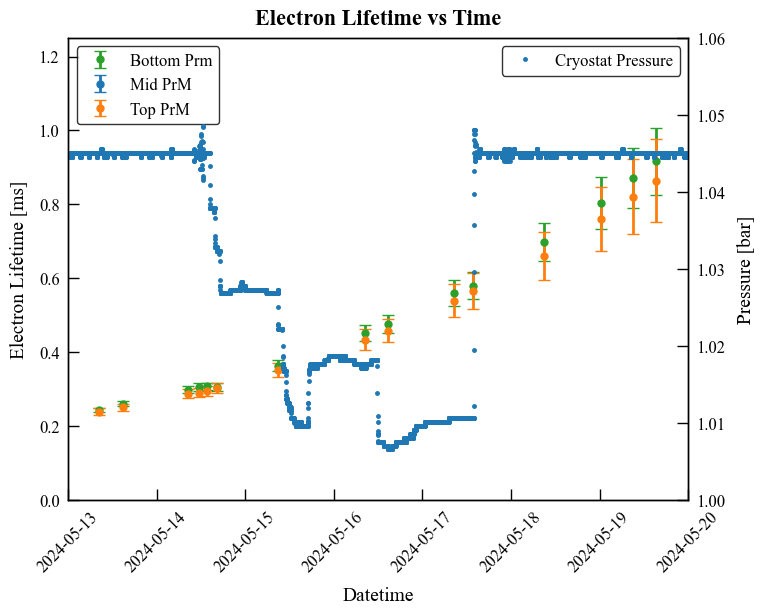

In [322]:
bot_purity = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/prm_Bot_lifetime_data_calibration_database.csv", header=0)
bot_purity["Timestamp"] = pd.to_datetime(bot_purity["Timestamp"], format="%Y-%m-%d %H:%M:%S")
bot_purity = bot_purity.set_index("Timestamp")

mid_purity = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/prm_Mid_lifetime_data_calibration_database.csv", header=0)
mid_purity["Timestamp"] = pd.to_datetime(mid_purity["Timestamp"], format="%Y-%m-%d %H:%M:%S")
mid_purity = mid_purity.set_index("Timestamp")

top_purity = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/prm_Top_lifetime_data_calibration_database.csv", header=0)
top_purity["Timestamp"] = pd.to_datetime(top_purity["Timestamp"], format="%Y-%m-%d %H:%M:%S")
top_purity = top_purity.set_index("Timestamp")

fig, axes = plt.subplots(figsize=(8, 6))
axes.errorbar(bot_purity.index.values, bot_purity["EleLifeTime_TPCCenter"], yerr=bot_purity["EleLifeTime_TPCHigh"] - bot_purity["EleLifeTime_TPCLow"], fmt="o", label="Bottom Prm", color="tab:green")
axes.errorbar(mid_purity.index.values, mid_purity["EleLifeTime_TPCCenter"], yerr=mid_purity["EleLifeTime_TPCHigh"] - mid_purity["EleLifeTime_TPCLow"], fmt="o", label="Mid PrM", color="tab:blue")
axes.errorbar(top_purity.index.values, top_purity["EleLifeTime_TPCCenter"], yerr=top_purity["EleLifeTime_TPCHigh"] - top_purity["EleLifeTime_TPCLow"], fmt="o", label="Top PrM", color="tab:orange")
axes.set_ylim(0,1.25)
axes.set_xlim(datetime.datetime(2024, 5, 13), datetime.datetime(2024, 5, 20))
axes.set_xlabel("Datetime")
axes.set_ylabel("Electron Lifetime [ms]")
axes.set_title("Electron Lifetime vs Time")
axes.legend(loc="upper left")
axes.tick_params(axis='x', rotation=45)
axes2 = axes.twinx()
axes2.plot(pressure1.data.index, pressure1.data.values, ".", label="Cryostat Pressure", color="tab:blue")
axes2.set_ylabel("Pressure [bar]")
axes2.legend(loc="upper right")
axes2.set_ylim(1, 1.06)

Text(0.5, 1.0, 'Cryostat and Ambient Pressure during Cryogenic Test')

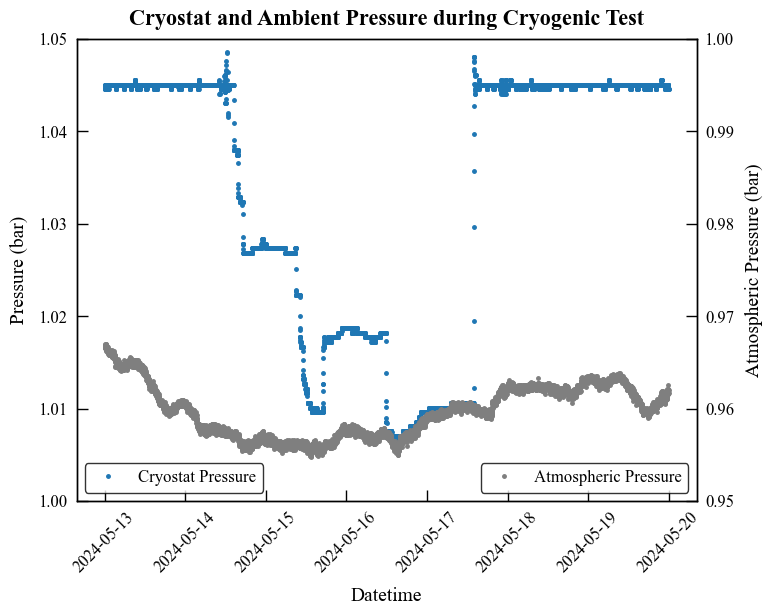

In [323]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pressure1.data.index, pressure1.data.values, ".", label="Cryostat Pressure", color="tab:blue")
axes.set_ylim(1.0, 1.05)
axes2 = axes.twinx()
axes2.plot(ambient_pressure.data.index, ambient_pressure.data.values/1000, ".", label="Atmospheric Pressure", color="tab:gray", alpha=1)
axes2.set_ylim(0.95, 1.0)
axes2.set_ylabel("Atmospheric Pressure (bar)")
axes2.legend(loc="lower right")
axes.tick_params(axis='x', rotation=45)
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure (bar)")
axes.legend(loc="lower left")
axes.set_title("Cryostat and Ambient Pressure during Cryogenic Test")

Text(0.5, 1.0, 'Pump Differential Pressure and LAr Flow during Cryogenic Test')

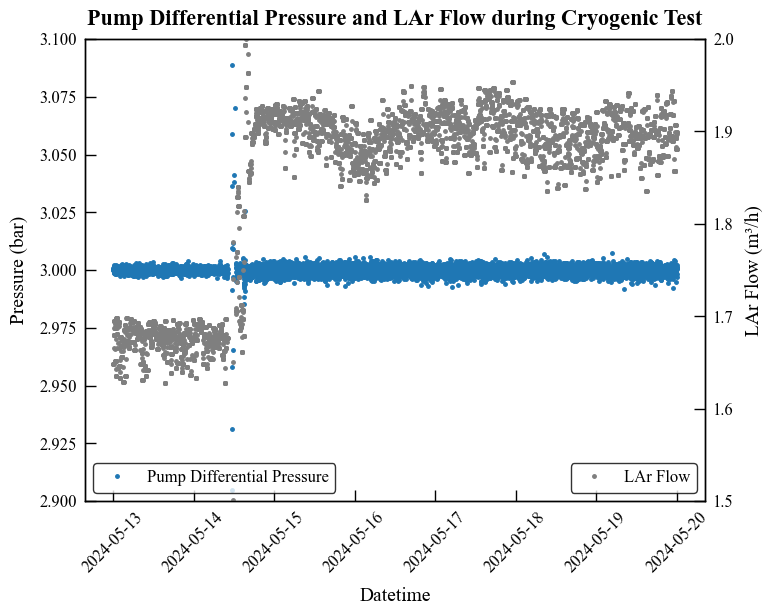

In [324]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pump_pressure.data.index, pump_pressure.data.values, ".", label="Pump Differential Pressure", color="tab:blue")
axes.set_ylim(2.9, 3.1)
axes2 = axes.twinx()
axes2.plot(lar_flow.data.index, lar_flow.data.values, ".", label="LAr Flow", color="tab:gray", alpha=1)
axes2.set_ylim(1.5, 2.0)
axes2.set_ylabel("LAr Flow (m³/h)")
axes2.legend(loc="lower right")
axes.tick_params(axis='x', rotation=45)
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure (bar)")
axes.legend(loc="lower left")
axes.set_title("Pump Differential Pressure and LAr Flow during Cryogenic Test")

Text(0.5, 1.0, 'LT0100 Level and Cryostat Pressure during Cryogenic Test')

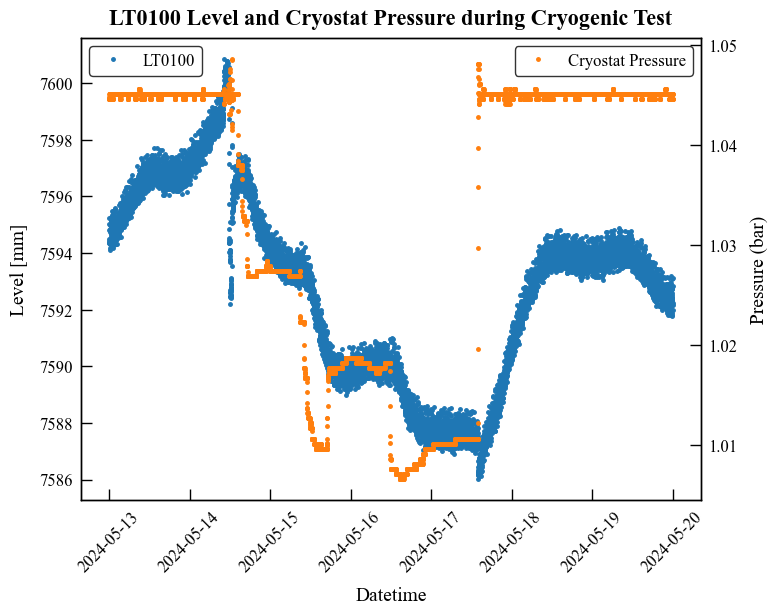

In [19]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(level1.data.index, level1.data.values, ".", label="LT0100", color="tab:blue")
axes.set_xlabel("Datetime")
axes.set_ylabel("Level [mm]")
axes.tick_params(axis='x', rotation=45)
axes.legend(loc="upper left")
axes2 = axes.twinx()
axes2.plot(pressure1.data.index, pressure1.data.values, ".", label="Cryostat Pressure", color="tab:orange")
axes2.set_ylabel("Pressure (bar)")
axes2.legend(loc="upper right")
axes.set_title("LT0100 Level and Cryostat Pressure during Cryogenic Test")
# axes.set_ylim(7550, 7650)

Text(0.5, 1.0, 'LT0100 Level and Cryostat Pressure during Cryogenic Test')

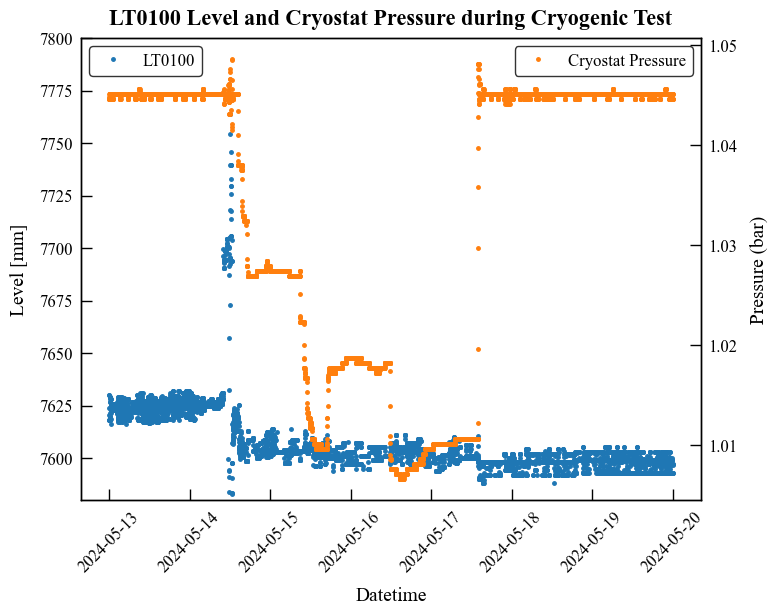

In [329]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(level2.data.index, cryostat_height*level2.data.values/100, ".", label="LT0100", color="tab:blue")
axes.set_xlabel("Datetime")
axes.set_ylabel("Level [mm]")
axes.set_ylim(7580, 7800)
axes.tick_params(axis='x', rotation=45)
axes.legend(loc="upper left")
axes2 = axes.twinx()
axes2.plot(pressure1.data.index, pressure1.data.values, ".", label="Cryostat Pressure", color="tab:orange")
axes2.set_ylabel("Pressure (bar)")
axes2.legend(loc="upper right")
axes.set_title("LT0100 Level and Cryostat Pressure during Cryogenic Test")
# axes.set_ylim(7550, 7650)

(-0.04, 0.02)

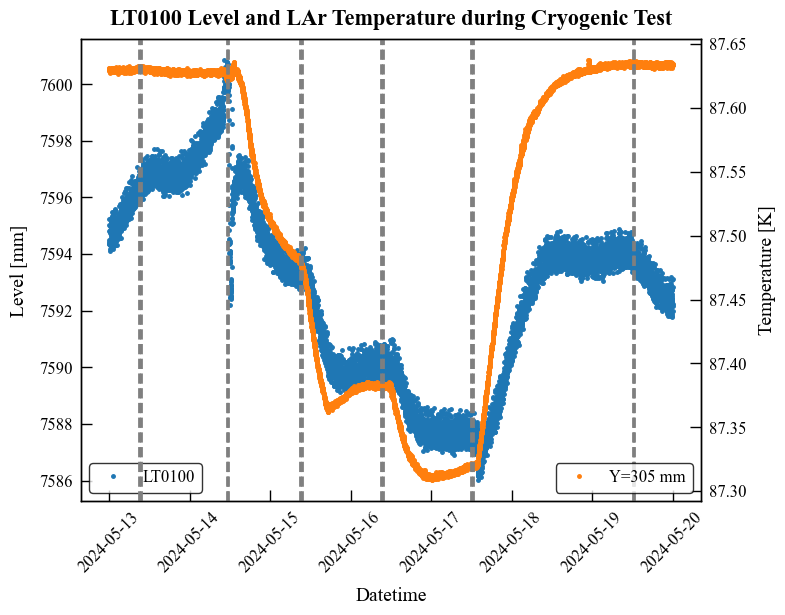

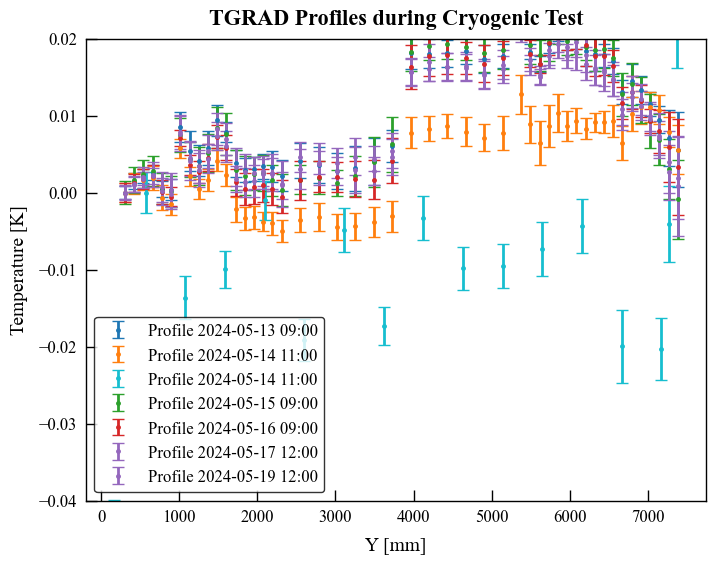

In [340]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(level1.data.index, level1.data.values, ".", label="LT0100", color="tab:blue")
axes.legend(loc="lower left")
axes.set_xlabel("Datetime")
axes.set_ylabel("Level [mm]")
axes2 = axes.twinx()
axes2.plot(tgrad.sensors[39607].data.index, tgrad.sensors[39607].data.values, ".", label=fr"Y={tgrad.sensors[39607].Y:.0f} mm", color="tab:orange")
axes2.legend(loc="lower right")
axes2.set_ylabel("Temperature [K]")
axes.set_title("LT0100 Level and LAr Temperature during Cryogenic Test")
axes.tick_params(axis='x', rotation=45)

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
deltat = datetime.timedelta(minutes=30)
t1 = datetime.datetime(2024, 5, 13, 9)
tgrad.makeProfiles(tini=t1, tend=t1 + deltat)
axes2.axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t1 + deltat, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"] == 305)].values[0], yerr=tgrad.profiles["err"].values, fmt=".", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}", color="tab:blue")

t2 = datetime.datetime(2024, 5, 14, 11)
tgrad.makeProfiles(tini=t2, tend=t2 + deltat)
axes2.axvline(t2, color="tab:gray", linestyle="--", label=f"Profile {t2.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t2 + deltat, color="tab:gray", linestyle="--", label=f"Profile {t2.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"] == 305)].values[0], yerr=tgrad.profiles["err"].values, fmt=".", label=f"Profile {t2.strftime('%Y-%m-%d %H:%M')}", color="tab:orange")
hawai.makeProfiles(tini=t2, tend=t2 + deltat)
axes.errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values - hawai.profiles["temp"].loc[(hawai.profiles["Y"] == 571)].values[0], yerr=hawai.profiles["err"].values, fmt=".", label=f"Profile {t2.strftime('%Y-%m-%d %H:%M')}", color="tab:cyan")


t3 = datetime.datetime(2024, 5, 15, 9)
tgrad.makeProfiles(tini=t3, tend=t3 + deltat)
axes2.axvline(t3, color="tab:gray", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t3 + deltat, color="tab:gray", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"] == 305)].values[0], yerr=tgrad.profiles["err"].values, fmt=".", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}", color="tab:green")

t4 = datetime.datetime(2024, 5, 16, 9)
tgrad.makeProfiles(tini=t4, tend=t4 + deltat)
axes2.axvline(t4, color="tab:gray", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t4 + deltat, color="tab:gray", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"] == 305)].values[0], yerr=tgrad.profiles["err"].values, fmt=".", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}", color="tab:red")

t5 = datetime.datetime(2024, 5, 17, 12)
tgrad.makeProfiles(tini=t5, tend=t5 + deltat)
axes2.axvline(t5, color="tab:gray", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t5 + deltat, color="tab:gray", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"] == 305)].values[0], yerr=tgrad.profiles["err"].values, fmt=".", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}", color="tab:purple")

t6 = datetime.datetime(2024, 5, 19, 12)
tgrad.makeProfiles(tini=t6, tend=t6 + deltat)
axes2.axvline(t6, color="tab:gray", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t6 + deltat, color="tab:gray", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"] == 305)].values[0], yerr=tgrad.profiles["err"].values, fmt=".", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}", color="tab:purple")

axes.set_xlabel("Y [mm]")
axes.set_ylabel("Temperature [K]")
axes.set_title("TGRAD Profiles during Cryogenic Test")
axes.legend(loc="best")
axes.set_ylim(-0.04, 0.02)

(-0.05, 0.025)

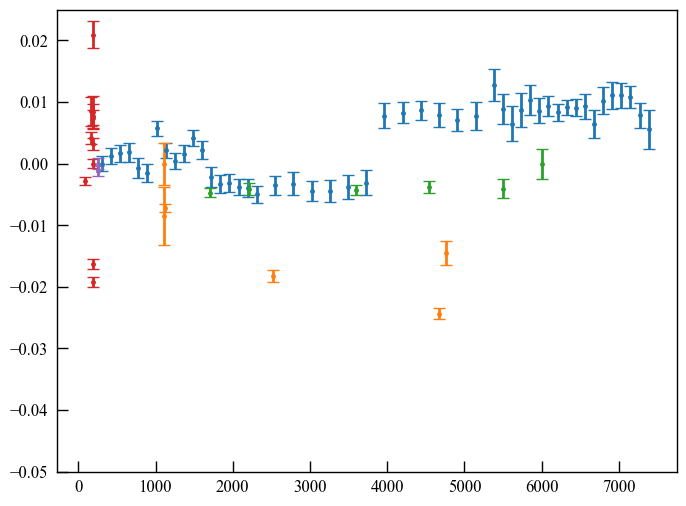

In [341]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
deltat = datetime.timedelta(minutes=30)
t1 = datetime.datetime(2024, 5, 14, 11)
tgrad.makeProfiles(tini=t1, tend=t1 + deltat)
axes.errorbar(tgrad.profiles["Y"].values, (tgrad.profiles["temp"]-tgrad.profiles["temp"].values[-1]).values, yerr=tgrad.profiles["err"].values, fmt=".", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}", color="tab:blue")
apa.makeProfiles(tini=t1, tend=t1 + deltat)
axes.errorbar(apa.profiles["Y"].values, (apa.profiles["temp"]-apa.profiles["temp"].values[-1]).values, yerr=apa.profiles["err"].values, fmt=".", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}", color="tab:orange")
prm.makeProfiles(tini=t1, tend=t1 + deltat)
axes.errorbar(prm.profiles["Y"].values, (prm.profiles["temp"]-prm.profiles["temp"].values[-1]).values, yerr=prm.profiles["err"].values, fmt=".", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}", color="tab:green")
pipe.makeProfiles(tini=t1, tend=t1 + deltat)
axes.errorbar(pipe.profiles["Y"].values, (pipe.profiles["temp"]-pipe.profiles["temp"].values[-1]).values, yerr=pipe.profiles["err"].values, fmt=".", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}", color="tab:red")
pump.makeProfiles(tini=t1, tend=t1 + deltat)
axes.errorbar(pump.profiles["Y"].values, (pump.profiles["temp"]-pump.profiles["temp"].values[-1]).values, yerr=pump.profiles["err"].values, fmt=".", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}", color="tab:purple")
axes.set_ylim(-0.05,0.025)

MUX1: t3-t1: -14.37 nA, t4-t1: -9.43 nA, t5-t1: -10.84 nA, t6-t1: -0.72 nA
MUX2: t3-t1: -1.27 nA, t4-t1: 3.63 nA, t5-t1: -34.05 nA, t6-t1: -27.30 nA
MUX3: t3-t1: 78.88 nA, t4-t1: 107.99 nA, t5-t1: 128.38 nA, t6-t1: -43.07 nA
MUX4: t3-t1: 12.59 nA, t4-t1: 52.56 nA, t5-t1: 52.12 nA, t6-t1: 2.43 nA


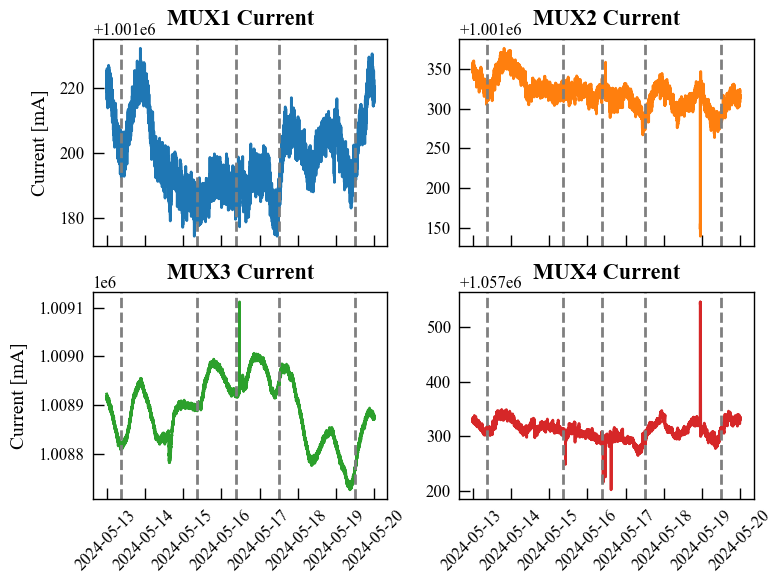

In [276]:
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True)
axes = axes.flatten()
axes[2].tick_params(axis='x', rotation=45)
axes[3].tick_params(axis='x', rotation=45)
axes[0].plot(mux1.data.index.values, 1e6*mux1.data.values, label=f"MUX1", color="tab:blue")
axes[1].plot(mux2.data.index.values, 1e6*mux2.data.values, label=f"MUX2", color="tab:orange")
axes[2].plot(mux3.data.index.values, 1e6*mux3.data.values, label=f"MUX3", color="tab:green")
axes[3].plot(mux4.data.index.values, 1e6*4.26/mux4.data.values, label=f"MUX4", color="tab:red")
axes[0].set_ylabel("Current [mA]")
axes[2].set_ylabel("Current [mA]")

axes[0].set_title("MUX1 Current")
axes[1].set_title("MUX2 Current")
axes[2].set_title("MUX3 Current")
axes[3].set_title("MUX4 Current")

mux1_t1 = mux1.data.loc[(mux1.data.index >= t1) & (mux1.data.index < t1 + deltat)].mean()
mux2_t1 = mux2.data.loc[(mux2.data.index >= t1) & (mux2.data.index < t1 + deltat)].mean()
mux3_t1 = mux3.data.loc[(mux3.data.index >= t1) & (mux3.data.index < t1 + deltat)].mean()
mux4_t1 = mux4.data.loc[(mux4.data.index >= t1) & (mux4.data.index < t1 + deltat)].mean()

axes[0].axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")
axes[1].axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")
axes[2].axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")
axes[3].axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")

mux1_t3 = mux1.data.loc[(mux1.data.index >= t3) & (mux1.data.index < t3 + deltat)].mean()
mux2_t3 = mux2.data.loc[(mux2.data.index >= t3) & (mux2.data.index < t3 + deltat)].mean()
mux3_t3 = mux3.data.loc[(mux3.data.index >= t3) & (mux3.data.index < t3 + deltat)].mean()
mux4_t3 = mux4.data.loc[(mux4.data.index >= t3) & (mux4.data.index < t3 + deltat)].mean()

axes[0].axvline(t3, color="tab:gray", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")
axes[1].axvline(t3, color="tab:gray", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")
axes[2].axvline(t3, color="tab:gray", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")
axes[3].axvline(t3, color="tab:gray", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")

mux1_t4 = mux1.data.loc[(mux1.data.index >= t4) & (mux1.data.index < t4 + deltat)].mean()
mux2_t4 = mux2.data.loc[(mux2.data.index >= t4) & (mux2.data.index < t4 + deltat)].mean()
mux3_t4 = mux3.data.loc[(mux3.data.index >= t4) & (mux3.data.index < t4 + deltat)].mean()
mux4_t4 = mux4.data.loc[(mux4.data.index >= t4) & (mux4.data.index < t4 + deltat)].mean()

axes[0].axvline(t4, color="tab:gray", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}")
axes[1].axvline(t4, color="tab:gray", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}")
axes[2].axvline(t4, color="tab:gray", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}")
axes[3].axvline(t4, color="tab:gray", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}")

mux1_t5 = mux1.data.loc[(mux1.data.index >= t5) & (mux1.data.index < t5 + deltat)].mean()
mux2_t5 = mux2.data.loc[(mux2.data.index >= t5) & (mux2.data.index < t5 + deltat)].mean()
mux3_t5 = mux3.data.loc[(mux3.data.index >= t5) & (mux3.data.index < t5 + deltat)].mean()
mux4_t5 = mux4.data.loc[(mux4.data.index >= t5) & (mux4.data.index < t5 + deltat)].mean()

axes[0].axvline(t5, color="tab:gray", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")
axes[1].axvline(t5, color="tab:gray", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")
axes[2].axvline(t5, color="tab:gray", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")
axes[3].axvline(t5, color="tab:gray", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")

mux1_t6 = mux1.data.loc[(mux1.data.index >= t6) & (mux1.data.index < t6 + deltat)].mean()
mux2_t6 = mux2.data.loc[(mux2.data.index >= t6) & (mux2.data.index < t6 + deltat)].mean()
mux3_t6 = mux3.data.loc[(mux3.data.index >= t6) & (mux3.data.index < t6 + deltat)].mean()
mux4_t6 = mux4.data.loc[(mux4.data.index >= t6) & (mux4.data.index < t6 + deltat)].mean()

axes[0].axvline(t6, color="tab:gray", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}")
axes[1].axvline(t6, color="tab:gray", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}")
axes[2].axvline(t6, color="tab:gray", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}")
axes[3].axvline(t6, color="tab:gray", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}")

print(f"MUX1: t3-t1: {1e6*(mux1_t3-mux1_t1):.2f} nA, t4-t1: {1e6*(mux1_t4-mux1_t1):.2f} nA, t5-t1: {1e6*(mux1_t5-mux1_t1):.2f} nA, t6-t1: {1e6*(mux1_t6-mux1_t1):.2f} nA")
print(f"MUX2: t3-t1: {1e6*(mux2_t3-mux2_t1):.2f} nA, t4-t1: {1e6*(mux2_t4-mux2_t1):.2f} nA, t5-t1: {1e6*(mux2_t5-mux2_t1):.2f} nA, t6-t1: {1e6*(mux2_t6-mux2_t1):.2f} nA")
print(f"MUX3: t3-t1: {1e6*(mux3_t3-mux3_t1):.2f} nA, t4-t1: {1e6*(mux3_t4-mux3_t1):.2f} nA, t5-t1: {1e6*(mux3_t5-mux3_t1):.2f} nA, t6-t1: {1e6*(mux3_t6-mux3_t1):.2f} nA")
print(f"MUX4: t3-t1: {1e6*(mux4_t3-mux4_t1):.2f} nA, t4-t1: {1e6*(mux4_t4-mux4_t1):.2f} nA, t5-t1: {1e6*(mux4_t5-mux4_t1):.2f} nA, t6-t1: {1e6*(mux4_t6-mux4_t1):.2f} nA")

fig.tight_layout()

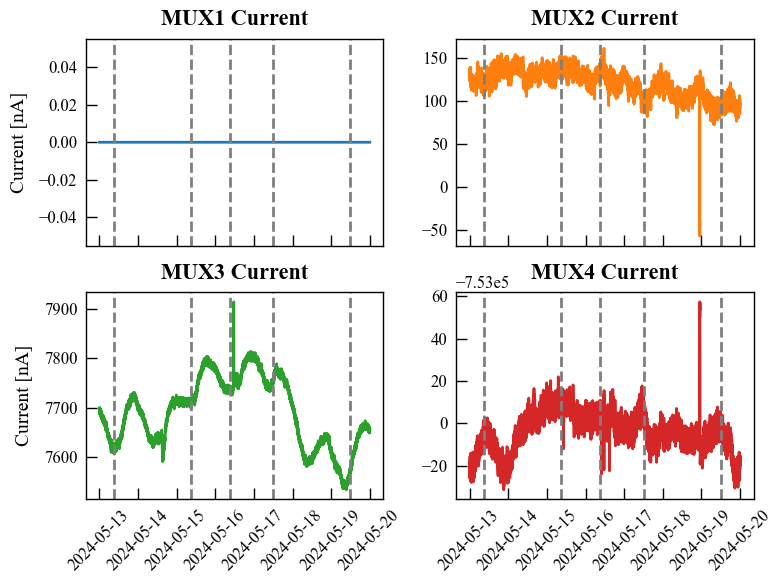

In [266]:
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True)
axes = axes.flatten()
axes[2].tick_params(axis='x', rotation=45)
axes[3].tick_params(axis='x', rotation=45)
axes[0].plot(mux1.data.index.values, 1e6*(mux1.data - mux1.data).values, label=f"MUX1", color="tab:blue")
axes[1].plot(mux2.data.index.values, 1e6*(mux2.data - mux1.data).values, label=f"MUX2", color="tab:orange")
axes[2].plot(mux3.data.index.values, 1e6*(mux3.data - mux1.data).values, label=f"MUX3", color="tab:green")
axes[3].plot(mux4.data.index.values, 1e6*((1/mux4.data) - mux1.data).values, label=f"MUX4", color="tab:red")
axes[0].set_ylabel("Current [nA]")
axes[2].set_ylabel("Current [nA]")

axes[0].set_title("MUX1 Current")
axes[1].set_title("MUX2 Current")
axes[2].set_title("MUX3 Current")
axes[3].set_title("MUX4 Current")

axes[0].axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")
axes[1].axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")
axes[2].axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")
axes[3].axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")

axes[0].axvline(t3, color="tab:gray", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")
axes[1].axvline(t3, color="tab:gray", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")
axes[2].axvline(t3, color="tab:gray", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")
axes[3].axvline(t3, color="tab:gray", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")

axes[0].axvline(t4, color="tab:gray", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}")
axes[1].axvline(t4, color="tab:gray", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}")
axes[2].axvline(t4, color="tab:gray", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}")
axes[3].axvline(t4, color="tab:gray", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}")

axes[0].axvline(t5, color="tab:gray", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")
axes[1].axvline(t5, color="tab:gray", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")
axes[2].axvline(t5, color="tab:gray", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")
axes[3].axvline(t5, color="tab:gray", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")

axes[0].axvline(t6, color="tab:gray", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}")
axes[1].axvline(t6, color="tab:gray", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}")
axes[2].axvline(t6, color="tab:gray", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}")
axes[3].axvline(t6, color="tab:gray", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}")

fig.tight_layout()

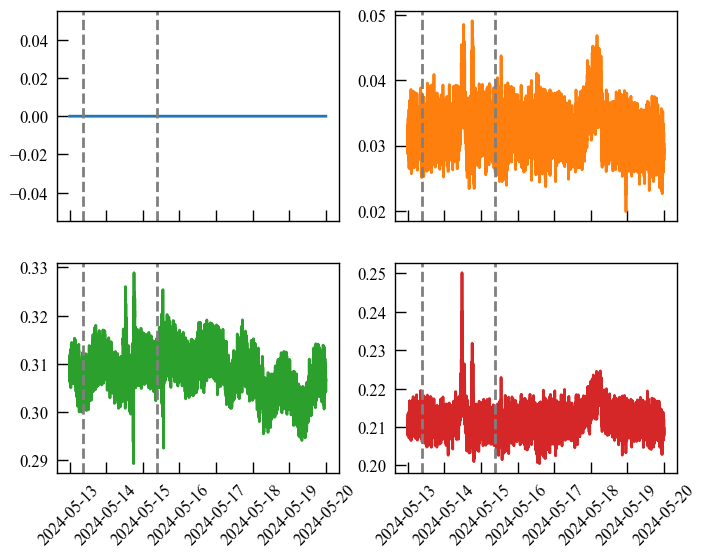

In [284]:
sensor1 = sensorClasses.Sensor(dataset=dataset, id=39644)
sensor2 = sensorClasses.Sensor(dataset=dataset, id=39607)
sensor3 = sensorClasses.Sensor(dataset=dataset, id=44125)
sensor4 = sensorClasses.Sensor(dataset=dataset, id=37127)

fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True)
axes = axes.flatten()
axes[2].tick_params(axis='x', rotation=45)
axes[3].tick_params(axis='x', rotation=45)
axes[0].plot(sensor1.data.index.values, (sensor1.data-sensor1.data).values, label=f"Sensor 39644", color="tab:blue")
axes[1].plot(sensor2.data.index.values, (sensor2.data-sensor1.data).values, label=f"Sensor 39607", color="tab:orange")
axes[2].plot(sensor3.data.index.values, (sensor3.data-sensor1.data).values, label=f"Sensor 44125", color="tab:green")
axes[3].plot(sensor4.data.index.values, (sensor4.data-sensor1.data).values, label=f"Sensor 37127", color="tab:red")

axes[0].axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")
axes[1].axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")
axes[2].axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")
axes[3].axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")

axes[0].axvline(t3, color="tab:gray", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")
axes[1].axvline(t3, color="tab:gray", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")
axes[2].axvline(t3, color="tab:gray", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")
axes[3].axvline(t3, color="tab:gray", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")


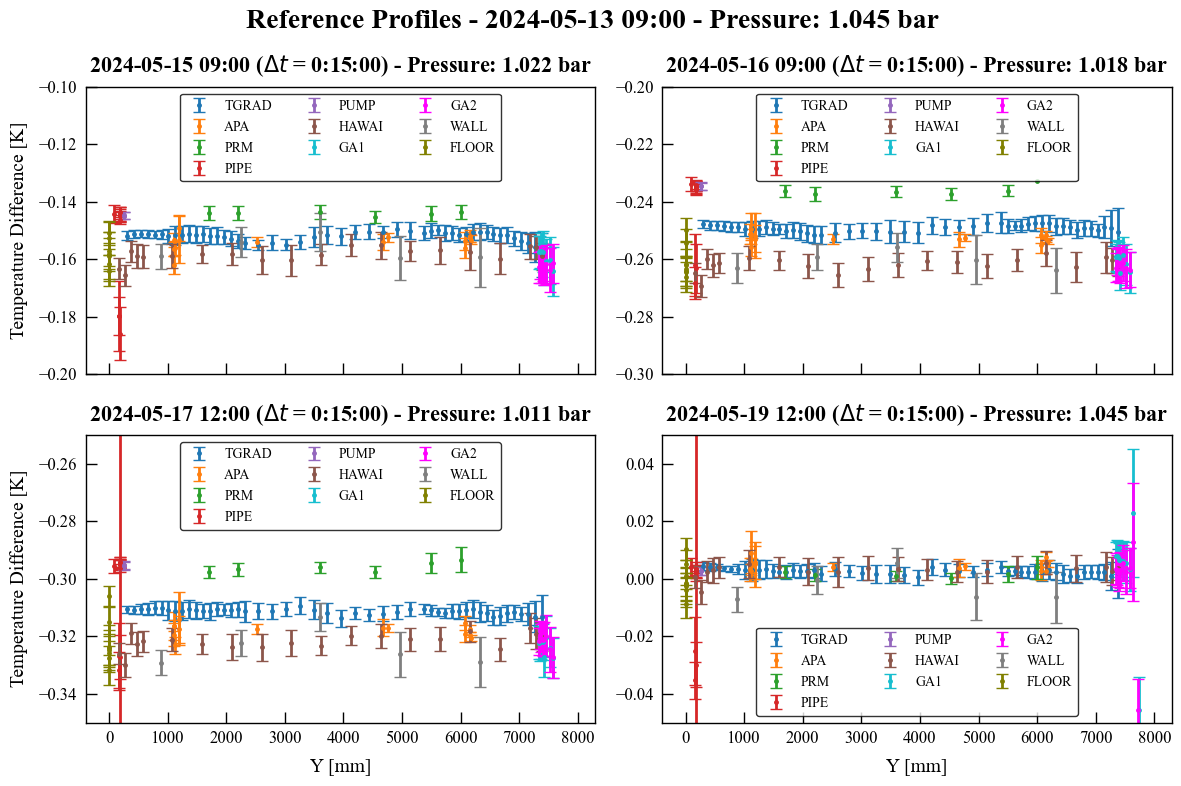

In [388]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
axes = axes.flatten()
deltat = datetime.timedelta(minutes=15)
t1 = datetime.datetime(2024, 5, 13, 9)
tgrad.makeProfiles(tini=t1, tend=t1 + deltat)
ref_tgrad_profile = tgrad.profiles
apa.makeProfiles(tini=t1, tend=t1 + deltat)
ref_apa_profile = apa.profiles
prm.makeProfiles(tini=t1, tend=t1 + deltat)
ref_prm_profile = prm.profiles
pipe.makeProfiles(tini=t1, tend=t1 + deltat)
ref_pipe_profile = pipe.profiles
pump.makeProfiles(tini=t1, tend=t1 + deltat)
ref_pump_profile = pump.profiles
hawai.makeProfiles(tini=t1, tend=t1 + deltat)
ref_hawai_profile = hawai.profiles
ga1.makeProfiles(tini=t1, tend=t1 + deltat)
ref_ga1_profile = ga1.profiles
ga2.makeProfiles(tini=t1, tend=t1 + deltat)
ref_ga2_profile = ga2.profiles
wall.makeProfiles(tini=t1, tend=t1 + deltat)
ref_wall_profile = wall.profiles
floor.makeProfiles(tini=t1, tend=t1 + deltat)
ref_floor_profile = floor.profiles

t3 = datetime.datetime(2024, 5, 15, 9)
tgrad.makeProfiles(tini=t3, tend=t3 + deltat)
current_tgrad_profile = tgrad.profiles
axes[0].errorbar(current_tgrad_profile["Y"].values, (current_tgrad_profile["temp"]-ref_tgrad_profile["temp"]).values  , yerr=np.sqrt(current_tgrad_profile["err"].values**2 + ref_tgrad_profile["err"].values**2), fmt=".", label=f"TGRAD", color="tab:blue")
apa.makeProfiles(tini=t3, tend=t3 + deltat)
current_apa_profile = apa.profiles
axes[0].errorbar(current_apa_profile["Y"].values, (current_apa_profile["temp"]-ref_apa_profile["temp"]).values , yerr=np.sqrt(current_apa_profile["err"].values**2 + ref_apa_profile["err"].values**2), fmt=".", label=f"APA", color="tab:orange")
prm.makeProfiles(tini=t3, tend=t3 + deltat)
current_prm_profile = prm.profiles
axes[0].errorbar(current_prm_profile["Y"].values, (current_prm_profile["temp"]-ref_prm_profile["temp"]).values , yerr=np.sqrt(current_prm_profile["err"].values**2 + ref_prm_profile["err"].values**2), fmt=".", label=f"PRM", color="tab:green")
pipe.makeProfiles(tini=t3, tend=t3 + deltat)
current_pipe_profile = pipe.profiles
axes[0].errorbar(current_pipe_profile["Y"].values, (current_pipe_profile["temp"]-ref_pipe_profile["temp"]).values , yerr=np.sqrt(current_pipe_profile["err"].values**2 + ref_pipe_profile["err"].values**2), fmt=".", label=f"PIPE", color="tab:red")
pump.makeProfiles(tini=t3, tend=t3 + deltat)
current_pump_profile = pump.profiles
axes[0].errorbar(current_pump_profile["Y"].values, (current_pump_profile["temp"]-ref_pump_profile["temp"]).values , yerr=np.sqrt(current_pump_profile["err"].values**2 + ref_pump_profile["err"].values**2), fmt=".", label=f"PUMP", color="tab:purple")
hawai.makeProfiles(tini=t3, tend=t3 + deltat)
current_hawai_profile = hawai.profiles
axes[0].errorbar(current_hawai_profile["Y"].values, (current_hawai_profile["temp"]-ref_hawai_profile["temp"]).values , yerr=np.sqrt(current_hawai_profile["err"].values**2 + ref_hawai_profile["err"].values**2), fmt=".", label=f"HAWAI", color="tab:brown")
ga1.makeProfiles(tini=t3, tend=t3 + deltat)
current_ga1_profile = ga1.profiles
axes[0].errorbar(current_ga1_profile["Y"].values, (current_ga1_profile["temp"]-ref_ga1_profile["temp"]).values , yerr=np.sqrt(current_ga1_profile["err"].values**2 + ref_ga1_profile["err"].values**2), fmt=".", label=f"GA1", color="tab:cyan")
ga2.makeProfiles(tini=t3, tend=t3 + deltat)
current_ga2_profile = ga2.profiles
axes[0].errorbar(current_ga2_profile["Y"].values, (current_ga2_profile["temp"]-ref_ga2_profile["temp"]).values , yerr=np.sqrt(current_ga2_profile["err"].values**2 + ref_ga2_profile["err"].values**2), fmt=".", label=f"GA2", color="magenta")
wall.makeProfiles(tini=t3, tend=t3 + deltat)
current_wall_profile = wall.profiles
axes[0].errorbar(current_wall_profile["Y"].values, (current_wall_profile["temp"]-ref_wall_profile["temp"]).values , yerr=np.sqrt(current_wall_profile["err"].values**2 + ref_wall_profile["err"].values**2), fmt=".", label=f"WALL", color="tab:gray")
floor.makeProfiles(tini=t3, tend=t3 + deltat)
current_floor_profile = floor.profiles
axes[0].errorbar(current_floor_profile["Y"].values, (current_floor_profile["temp"]-ref_floor_profile["temp"]).values , yerr=np.sqrt(current_floor_profile["err"].values**2 + ref_floor_profile["err"].values**2), fmt=".", label=f"FLOOR", color="olive")

t4 = datetime.datetime(2024, 5, 16, 9)
tgrad.makeProfiles(tini=t4, tend=t4 + deltat)
current_tgrad_profile = tgrad.profiles
axes[1].errorbar(current_tgrad_profile["Y"].values, (current_tgrad_profile["temp"]-ref_tgrad_profile["temp"]).values , yerr=np.sqrt(current_tgrad_profile["err"].values**2 + ref_tgrad_profile["err"].values**2), fmt=".", label=f"TGRAD", color="tab:blue")
apa.makeProfiles(tini=t4, tend=t4 + deltat)
current_apa_profile = apa.profiles
axes[1].errorbar(current_apa_profile["Y"].values, (current_apa_profile["temp"]-ref_apa_profile["temp"]).values , yerr=np.sqrt(current_apa_profile["err"].values**2 + ref_apa_profile["err"].values**2), fmt=".", label=f"APA", color="tab:orange")
prm.makeProfiles(tini=t4, tend=t4 + deltat)
current_prm_profile = prm.profiles
axes[1].errorbar(current_prm_profile["Y"].values, (current_prm_profile["temp"]-ref_prm_profile["temp"]).values , yerr=np.sqrt(current_prm_profile["err"].values**2 + ref_prm_profile["err"].values**2), fmt=".", label=f"PRM", color="tab:green")
pipe.makeProfiles(tini=t4, tend=t4 + deltat)
current_pipe_profile = pipe.profiles
axes[1].errorbar(current_pipe_profile["Y"].values, (current_pipe_profile["temp"]-ref_pipe_profile["temp"]).values , yerr=np.sqrt(current_pipe_profile["err"].values**2 + ref_pipe_profile["err"].values**2), fmt=".", label=f"PIPE", color="tab:red");
pump.makeProfiles(tini=t4, tend=t4 + deltat)
current_pump_profile = pump.profiles
axes[1].errorbar(current_pump_profile["Y"].values, (current_pump_profile["temp"]-ref_pump_profile["temp"]).values , yerr=np.sqrt(current_pump_profile["err"].values**2 + ref_pump_profile["err"].values**2), fmt=".", label=f"PUMP", color="tab:purple");
hawai.makeProfiles(tini=t4, tend=t4 + deltat)
current_hawai_profile = hawai.profiles
axes[1].errorbar(current_hawai_profile["Y"].values, (current_hawai_profile["temp"]-ref_hawai_profile["temp"]).values , yerr=np.sqrt(current_hawai_profile["err"].values**2 + ref_hawai_profile["err"].values**2), fmt=".", label=f"HAWAI", color="tab:brown")
ga1.makeProfiles(tini=t4, tend=t4 + deltat)
current_ga1_profile = ga1.profiles
axes[1].errorbar(current_ga1_profile["Y"].values, (current_ga1_profile["temp"]-ref_ga1_profile["temp"]).values , yerr=np.sqrt(current_ga1_profile["err"].values**2 + ref_ga1_profile["err"].values**2), fmt=".", label=f"GA1", color="tab:cyan")
ga2.makeProfiles(tini=t4, tend=t4 + deltat)
current_ga2_profile = ga2.profiles
axes[1].errorbar(current_ga2_profile["Y"].values, (current_ga2_profile["temp"]-ref_ga2_profile["temp"]).values , yerr=np.sqrt(current_ga2_profile["err"].values**2 + ref_ga2_profile["err"].values**2), fmt=".", label=f"GA2", color="magenta")
wall.makeProfiles(tini=t4, tend=t4 + deltat)
current_wall_profile = wall.profiles
axes[1].errorbar(current_wall_profile["Y"].values, (current_wall_profile["temp"]-ref_wall_profile["temp"]).values , yerr=np.sqrt(current_wall_profile["err"].values**2 + ref_wall_profile["err"].values**2), fmt=".", label=f"WALL", color="tab:gray")
floor.makeProfiles(tini=t4, tend=t4 + deltat)
current_floor_profile = floor.profiles
axes[1].errorbar(current_floor_profile["Y"].values, (current_floor_profile["temp"]-ref_floor_profile["temp"]).values , yerr=np.sqrt(current_floor_profile["err"].values**2 + ref_floor_profile["err"].values**2), fmt=".", label=f"FLOOR", color="olive")

t5 = datetime.datetime(2024, 5, 17, 12)
tgrad.makeProfiles(tini=t5, tend=t5 + deltat)
current_tgrad_profile = tgrad.profiles
axes[2].errorbar(current_tgrad_profile["Y"].values, (current_tgrad_profile["temp"]-ref_tgrad_profile["temp"]).values , yerr=np.sqrt(current_tgrad_profile["err"].values**2 + ref_tgrad_profile["err"].values**2), fmt=".", label=f"TGRAD", color="tab:blue")
apa.makeProfiles(tini=t5, tend=t5 + deltat)
current_apa_profile = apa.profiles
axes[2].errorbar(current_apa_profile["Y"].values, (current_apa_profile["temp"]-ref_apa_profile["temp"]).values , yerr=np.sqrt(current_apa_profile["err"].values**2 + ref_apa_profile["err"].values**2), fmt=".", label=f"APA", color="tab:orange")
prm.makeProfiles(tini=t5, tend=t5 + deltat)
current_prm_profile = prm.profiles
axes[2].errorbar(current_prm_profile["Y"].values, (current_prm_profile["temp"]-ref_prm_profile["temp"]).values , yerr=np.sqrt(current_prm_profile["err"].values**2 + ref_prm_profile["err"].values**2), fmt=".", label=f"PRM", color="tab:green")
pipe.makeProfiles(tini=t5, tend=t5 + deltat)
current_pipe_profile = pipe.profiles
axes[2].errorbar(current_pipe_profile["Y"].values, (current_pipe_profile["temp"]-ref_pipe_profile["temp"]).values , yerr=np.sqrt(current_pipe_profile["err"].values**2 + ref_pipe_profile["err"].values**2), fmt=".", label=f"PIPE", color="tab:red")
pump.makeProfiles(tini=t5, tend=t5 + deltat)
current_pump_profile = pump.profiles
axes[2].errorbar(current_pump_profile["Y"].values, (current_pump_profile["temp"]-ref_pump_profile["temp"]).values , yerr=np.sqrt(current_pump_profile["err"].values**2 + ref_pump_profile["err"].values**2), fmt=".", label=f"PUMP", color="tab:purple");
hawai.makeProfiles(tini=t5, tend=t5 + deltat)
current_hawai_profile = hawai.profiles
axes[2].errorbar(current_hawai_profile["Y"].values, (current_hawai_profile["temp"]-ref_hawai_profile["temp"]).values , yerr=np.sqrt(current_hawai_profile["err"].values**2 + ref_hawai_profile["err"].values**2), fmt=".", label=f"HAWAI", color="tab:brown")
ga1.makeProfiles(tini=t5, tend=t5 + deltat)
current_ga1_profile = ga1.profiles
axes[2].errorbar(current_ga1_profile["Y"].values, (current_ga1_profile["temp"]-ref_ga1_profile["temp"]).values , yerr=np.sqrt(current_ga1_profile["err"].values**2 + ref_ga1_profile["err"].values**2), fmt=".", label=f"GA1", color="tab:cyan")
ga2.makeProfiles(tini=t5, tend=t5 + deltat)
current_ga2_profile = ga2.profiles
axes[2].errorbar(current_ga2_profile["Y"].values, (current_ga2_profile["temp"]-ref_ga2_profile["temp"]).values , yerr=np.sqrt(current_ga2_profile["err"].values**2 + ref_ga2_profile["err"].values**2), fmt=".", label=f"GA2", color="magenta")
wall.makeProfiles(tini=t5, tend=t5 + deltat)
current_wall_profile = wall.profiles
axes[2].errorbar(current_wall_profile["Y"].values, (current_wall_profile["temp"]-ref_wall_profile["temp"]).values , yerr=np.sqrt(current_wall_profile["err"].values**2 + ref_wall_profile["err"].values**2), fmt=".", label=f"WALL", color="tab:gray")
floor.makeProfiles(tini=t5, tend=t5 + deltat)
current_floor_profile = floor.profiles
axes[2].errorbar(current_floor_profile["Y"].values, (current_floor_profile["temp"]-ref_floor_profile["temp"]).values , yerr=np.sqrt(current_floor_profile["err"].values**2 + ref_floor_profile["err"].values**2), fmt=".", label=f"FLOOR", color="olive")

t6 = datetime.datetime(2024, 5, 19, 12)
tgrad.makeProfiles(tini=t6, tend=t6 + deltat)
current_tgrad_profile = tgrad.profiles
axes[3].errorbar(current_tgrad_profile["Y"].values, (current_tgrad_profile["temp"]-ref_tgrad_profile["temp"]).values , yerr=np.sqrt(current_tgrad_profile["err"].values**2 + ref_tgrad_profile["err"].values**2), fmt=".", label=f"TGRAD", color="tab:blue")
apa.makeProfiles(tini=t6, tend=t6 + deltat)
current_apa_profile = apa.profiles
axes[3].errorbar(current_apa_profile["Y"].values, (current_apa_profile["temp"]-ref_apa_profile["temp"]).values , yerr=np.sqrt(current_apa_profile["err"].values**2 + ref_apa_profile["err"].values**2), fmt=".", label=f"APA", color="tab:orange")
prm.makeProfiles(tini=t6, tend=t6 + deltat)
current_prm_profile = prm.profiles
axes[3].errorbar(current_prm_profile["Y"].values, (current_prm_profile["temp"]-ref_prm_profile["temp"]).values , yerr=np.sqrt(current_prm_profile["err"].values**2 + ref_prm_profile["err"].values**2), fmt=".", label=f"PRM", color="tab:green")
pipe.makeProfiles(tini=t6, tend=t6 + deltat)
current_pipe_profile = pipe.profiles
axes[3].errorbar(current_pipe_profile["Y"].values, (current_pipe_profile["temp"]-ref_pipe_profile["temp"]).values , yerr=np.sqrt(current_pipe_profile["err"].values**2 + ref_pipe_profile["err"].values**2), fmt=".", label=f"PIPE", color="tab:red")
pump.makeProfiles(tini=t6, tend=t6 + deltat)
current_pump_profile = pump.profiles
axes[3].errorbar(current_pump_profile["Y"].values, (current_pump_profile["temp"]-ref_pump_profile["temp"]).values , yerr=np.sqrt(current_pump_profile["err"].values**2 + ref_pump_profile["err"].values**2), fmt=".", label=f"PUMP", color="tab:purple");
hawai.makeProfiles(tini=t6, tend=t6 + deltat)
current_hawai_profile = hawai.profiles
axes[3].errorbar(current_hawai_profile["Y"].values, (current_hawai_profile["temp"]-ref_hawai_profile["temp"]).values , yerr=np.sqrt(current_hawai_profile["err"].values**2 + ref_hawai_profile["err"].values**2), fmt=".", label=f"HAWAI", color="tab:brown")
ga1.makeProfiles(tini=t6, tend=t6 + deltat)
current_ga1_profile = ga1.profiles
axes[3].errorbar(current_ga1_profile["Y"].values, (current_ga1_profile["temp"]-ref_ga1_profile["temp"]).values , yerr=np.sqrt(current_ga1_profile["err"].values**2 + ref_ga1_profile["err"].values**2), fmt=".", label=f"GA1", color="tab:cyan")
ga2.makeProfiles(tini=t6, tend=t6 + deltat)
current_ga2_profile = ga2.profiles
axes[3].errorbar(current_ga2_profile["Y"].values, (current_ga2_profile["temp"]-ref_ga2_profile["temp"]).values , yerr=np.sqrt(current_ga2_profile["err"].values**2 + ref_ga2_profile["err"].values**2), fmt=".", label=f"GA2", color="magenta")
wall.makeProfiles(tini=t6, tend=t6 + deltat)
current_wall_profile = wall.profiles
axes[3].errorbar(current_wall_profile["Y"].values, (current_wall_profile["temp"]-ref_wall_profile["temp"]).values , yerr=np.sqrt(current_wall_profile["err"].values**2 + ref_wall_profile["err"].values**2), fmt=".", label=f"WALL", color="tab:gray")
floor.makeProfiles(tini=t6, tend=t6 + deltat)
current_floor_profile = floor.profiles
axes[3].errorbar(current_floor_profile["Y"].values, (current_floor_profile["temp"]-ref_floor_profile["temp"]).values , yerr=np.sqrt(current_floor_profile["err"].values**2 + ref_floor_profile["err"].values**2), fmt=".", label=f"FLOOR", color="olive")

p1 = pressure1.data.loc[(pressure1.data.index >= t1) & (pressure1.data.index < t1 + deltat)].mean()
p3 = pressure1.data.loc[(pressure1.data.index >= t3) & (pressure1.data.index < t3 + deltat)].mean()
p4 = pressure1.data.loc[(pressure1.data.index >= t4) & (pressure1.data.index < t4 + deltat)].mean()
p5 = pressure1.data.loc[(pressure1.data.index >= t5) & (pressure1.data.index < t5 + deltat)].mean()
p6 = pressure1.data.loc[(pressure1.data.index >= t6) & (pressure1.data.index < t6 + deltat)].mean()

# axes[0].set_ylim(-0.025, 0.025)
axes[0].set_ylim(-0.2, -0.1)
axes[1].set_ylim(-0.3, -0.2)
axes[2].set_ylim(-0.35, -0.25)
axes[3].set_ylim(-0.05, 0.05)
# axes[0].set_xlabel("Y [mm]")
axes[0].set_ylabel("Temperature Difference [K]")
axes[0].set_title(fr"{t3.strftime('%Y-%m-%d %H:%M')} ($\Delta t$ = {deltat}) - Pressure: {p3:.3f} bar")
axes[0].legend(loc="upper center", fontsize="small", ncol=3)

axes[1].legend(loc="best", fontsize="small", ncol=3)
axes[1].set_title(fr"{t4.strftime('%Y-%m-%d %H:%M')} ($\Delta t$ = {deltat}) - Pressure: {p4:.3f} bar")

axes[2].set_xlabel("Y [mm]")
axes[2].set_ylabel("Temperature Difference [K]")
axes[2].set_title(fr"{t5.strftime('%Y-%m-%d %H:%M')} ($\Delta t$ = {deltat}) - Pressure: {p5:.3f} bar")
axes[2].legend(loc="best", fontsize="small", ncol=3)

axes[3].set_xlabel("Y [mm]")
axes[3].set_title(fr"{t6.strftime('%Y-%m-%d %H:%M')} ($\Delta t$ = {deltat}) - Pressure: {p6:.3f} bar")
axes[3].legend(loc="best", fontsize="small", ncol=3)

fig.suptitle(fr"Reference Profiles - {t1.strftime('%Y-%m-%d %H:%M')} - Pressure: {p1:.3f} bar", fontsize=20, fontweight="bold")
fig.tight_layout()

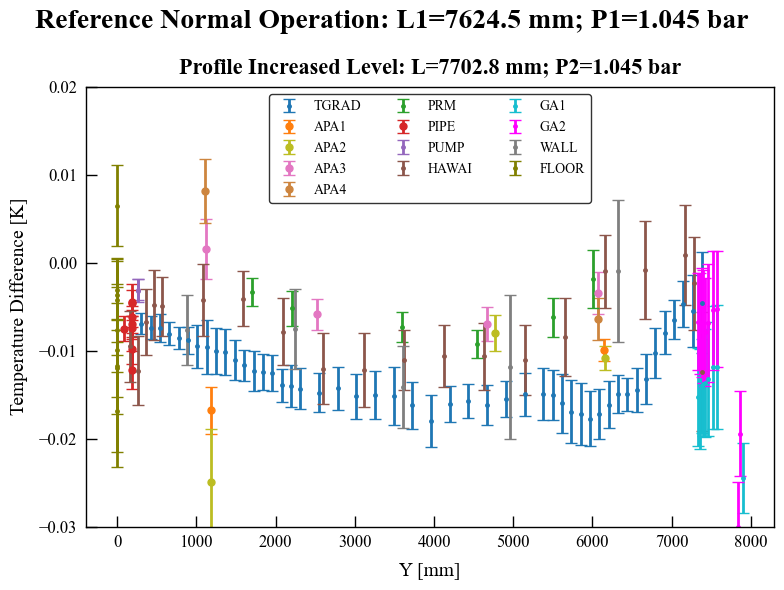

In [387]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6), sharex=True, sharey=False)

mask1 = apa.profiles["name"].str.contains("APA1", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask2 = apa.profiles["name"].str.contains("APA2", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask3 = apa.profiles["name"].str.contains("APA3", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask4 = apa.profiles["name"].str.contains("APA4", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask5 = pipe.profiles["name"].str.contains("-", na=False) & ~pipe.profiles["name"].str.contains("I", na=False)
# mask5 = pipe.profiles["name"].str.contains("-", na=False) & pipe.profiles["name"].str.contains("1-U", na=False)
# mask6 = pipe.profiles["name"].str.contains("-", na=False) & pipe.profiles["name"].str.contains("1-M", na=False)
# mask7 = pipe.profiles["name"].str.contains("-", na=False) & pipe.profiles["name"].str.contains("4-U", na=False)
# mask8 = pipe.profiles["name"].str.contains("-", na=False) & pipe.profiles["name"].str.contains("4-M", na=False)

t2 = datetime.datetime(2024, 5, 14, 11)
tgrad.makeProfiles(tini=t2, tend=t2 + deltat)
current_tgrad_profile = tgrad.profiles
axes.errorbar(current_tgrad_profile["Y"].values, (current_tgrad_profile["temp"]-ref_tgrad_profile["temp"]).values  , yerr=np.sqrt(current_tgrad_profile["err"].values**2 + ref_tgrad_profile["err"].values**2), fmt=".", label=f"TGRAD", color="tab:blue")
apa.makeProfiles(tini=t2, tend=t2 + deltat)
current_apa_profile = apa.profiles
axes.errorbar(
    current_apa_profile.loc[mask1, "Y"].values,
    (current_apa_profile.loc[mask1, "temp"]-ref_apa_profile.loc[mask1, "temp"]).values,
    yerr=np.sqrt(current_apa_profile.loc[mask1, "err"].values**2 + ref_apa_profile.loc[mask1, "err"].values**2),
    fmt='o',
    label="APA1",
    color="tab:orange"
)
axes.errorbar(
    current_apa_profile.loc[mask2, "Y"].values,
    (current_apa_profile.loc[mask2, "temp"]-ref_apa_profile.loc[mask2, "temp"]).values,
    yerr=np.sqrt(current_apa_profile.loc[mask2, "err"].values**2 + ref_apa_profile.loc[mask2, "err"].values**2),
    fmt='o',
    label="APA2",
    color="tab:olive"
)
axes.errorbar(
    current_apa_profile.loc[mask3, "Y"].values,
    (current_apa_profile.loc[mask3, "temp"]-ref_apa_profile.loc[mask3, "temp"]).values,
    yerr=np.sqrt(current_apa_profile.loc[mask3, "err"].values**2 + ref_apa_profile.loc[mask3, "err"].values**2),
    fmt='o',
    label="APA3",
    color="tab:pink"
)
axes.errorbar(
    current_apa_profile.loc[mask4, "Y"].values,
    (current_apa_profile.loc[mask4, "temp"]-ref_apa_profile.loc[mask4, "temp"]).values,
    yerr=np.sqrt(current_apa_profile.loc[mask4, "err"].values**2 + ref_apa_profile.loc[mask4, "err"].values**2),
    fmt='o',
    label="APA4",
    color="peru"
)
# axes.errorbar(current_apa_profile["Y"].values, (current_apa_profile["temp"]-ref_apa_profile["temp"]).values , yerr=np.sqrt(current_apa_profile["err"].values**2 + ref_apa_profile["err"].values**2), fmt=".", label=f"APA", color="tab:orange")
prm.makeProfiles(tini=t2, tend=t2 + deltat)
current_prm_profile = prm.profiles
axes.errorbar(current_prm_profile["Y"].values, (current_prm_profile["temp"]-ref_prm_profile["temp"]).values , yerr=np.sqrt(current_prm_profile["err"].values**2 + ref_prm_profile["err"].values**2), fmt=".", label=f"PRM", color="tab:green")
pipe.makeProfiles(tini=t2, tend=t2 + deltat)
current_pipe_profile = pipe.profiles
axes.errorbar(
    current_pipe_profile.loc[mask5, "Y"].values,
    (current_pipe_profile.loc[mask5, "temp"]-ref_pipe_profile.loc[mask5, "temp"]).values,
    yerr=np.sqrt(current_pipe_profile.loc[mask5, "err"].values**2 + ref_pipe_profile.loc[mask5, "err"].values**2),
    fmt='o',
    label="PIPE",
    color="tab:red"
)
pump.makeProfiles(tini=t2, tend=t2 + deltat)
current_pump_profile = pump.profiles
axes.errorbar(current_pump_profile["Y"].values, (current_pump_profile["temp"]-ref_pump_profile["temp"]).values , yerr=np.sqrt(current_pump_profile["err"].values**2 + ref_pump_profile["err"].values**2), fmt=".", label=f"PUMP", color="tab:purple")
hawai.makeProfiles(tini=t2, tend=t2 + deltat)
current_hawai_profile = hawai.profiles
axes.errorbar(current_hawai_profile["Y"].values, (current_hawai_profile["temp"]-ref_hawai_profile["temp"]).values , yerr=np.sqrt(current_hawai_profile["err"].values**2 + ref_hawai_profile["err"].values**2), fmt=".", label=f"HAWAI", color="tab:brown")
ga1.makeProfiles(tini=t2, tend=t2 + deltat)
current_ga1_profile = ga1.profiles
axes.errorbar(current_ga1_profile["Y"].values, (current_ga1_profile["temp"]-ref_ga1_profile["temp"]).values , yerr=np.sqrt(current_ga1_profile["err"].values**2 + ref_ga1_profile["err"].values**2), fmt=".", label=f"GA1", color="tab:cyan")
ga2.makeProfiles(tini=t2, tend=t2 + deltat)
current_ga2_profile = ga2.profiles
axes.errorbar(current_ga2_profile["Y"].values, (current_ga2_profile["temp"]-ref_ga2_profile["temp"]).values , yerr=np.sqrt(current_ga2_profile["err"].values**2 + ref_ga2_profile["err"].values**2), fmt=".", label=f"GA2", color="magenta")
wall.makeProfiles(tini=t2, tend=t2 + deltat)
current_wall_profile = wall.profiles
axes.errorbar(current_wall_profile["Y"].values, (current_wall_profile["temp"]-ref_wall_profile["temp"]).values , yerr=np.sqrt(current_wall_profile["err"].values**2 + ref_wall_profile["err"].values**2), fmt=".", label=f"WALL", color="tab:gray")
floor.makeProfiles(tini=t2, tend=t2 + deltat)
current_floor_profile = floor.profiles
axes.errorbar(current_floor_profile["Y"].values, (current_floor_profile["temp"]-ref_floor_profile["temp"]).values , yerr=np.sqrt(current_floor_profile["err"].values**2 + ref_floor_profile["err"].values**2), fmt=".", label=f"FLOOR", color="olive")

l1 = cryostat_height*level2.data.loc[(level2.data.index >= t1) & (level2.data.index < t1 + deltat)].mean()/100
p1 = pressure1.data.loc[(pressure1.data.index >= t1) & (pressure1.data.index < t1 + deltat)].mean()
l2 = cryostat_height*level2.data.loc[(level2.data.index >= t2) & (level2.data.index < t2 + deltat)].mean()/100
p2 = pressure1.data.loc[(pressure1.data.index >= t2) & (pressure1.data.index < t2 + deltat)].mean()
axes.set_title(f"Profile Increased Level: L={l2:.1f} mm; P2={p2:.3f} bar", fontweight="bold")
axes.set_ylim(-0.03, 0.02)
axes.legend(ncol=3, fontsize="small", loc="best")
axes.set_xlabel("Y [mm]")
axes.set_ylabel("Temperature Difference [K]")
fig.suptitle(f"Reference Normal Operation: L1={l1:.1f} mm; P1={p1:.3f} bar", fontsize=20, fontweight="bold")
fig.tight_layout()

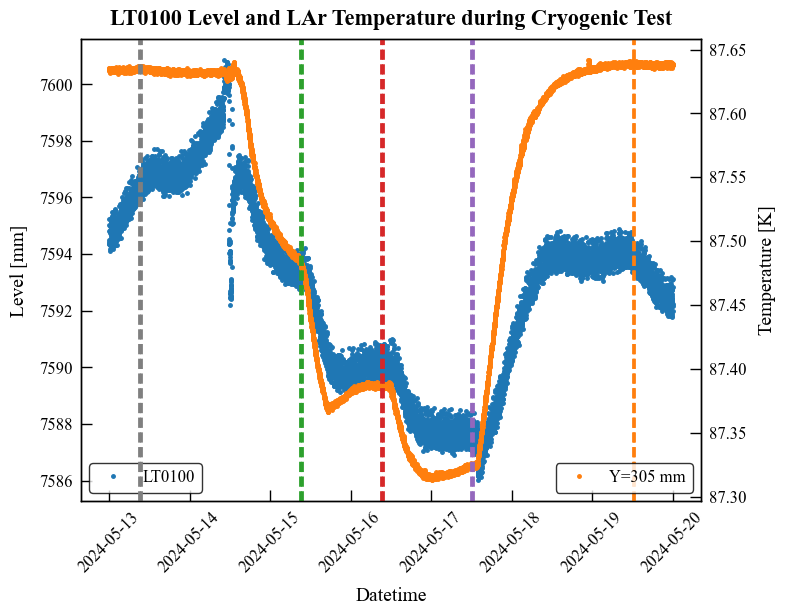

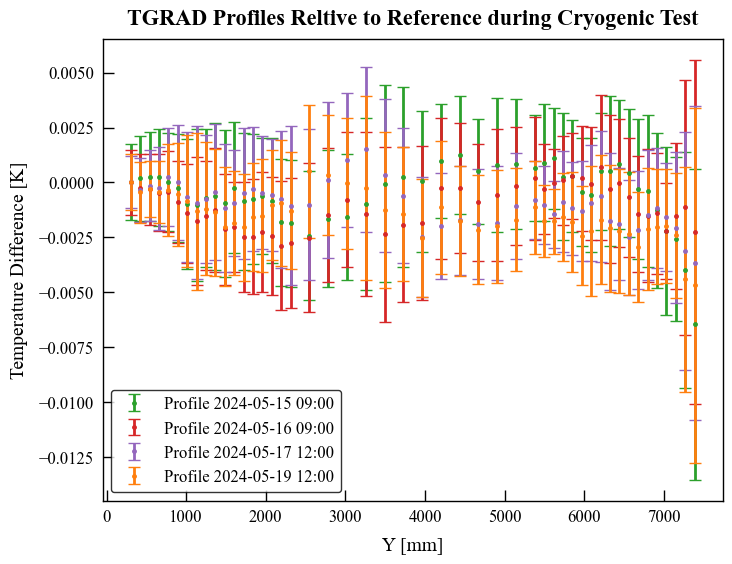

In [179]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(level1.data.index, level1.data.values, ".", label="LT0100", color="tab:blue")
axes.legend(loc="lower left")
axes.set_xlabel("Datetime")
axes.set_ylabel("Level [mm]")
axes2 = axes.twinx()
axes2.plot(tgrad.sensors[39607].data.index, tgrad.sensors[39607].data.values, ".", label=fr"Y={tgrad.sensors[39607].Y:.0f} mm", color="tab:orange")
axes2.legend(loc="lower right")
axes2.set_ylabel("Temperature [K]")
axes.set_title("LT0100 Level and LAr Temperature during Cryogenic Test")
axes.tick_params(axis='x', rotation=45)

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
deltat = datetime.timedelta(minutes=30)
t1 = datetime.datetime(2024, 5, 13, 9)
tgrad.makeProfiles(tini=t1, tend=t1 + deltat)
ref_profile = tgrad.profiles
axes2.axvline(t1, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t1 + deltat, color="tab:gray", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')} - {deltat}")
# axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"] == 305)].values[0], yerr=tgrad.profiles["err"].values, fmt=".", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}", color="tab:blue")

# t2 = datetime.datetime(2024, 5, 14, 9)
# tgrad.makeProfiles(tini=t2, tend=t2 + deltat)
# axes2.axvline(t2, color="tab:gray", linestyle="--", label=f"Profile {t2.strftime('%Y-%m-%d %H:%M')}")
# axes2.axvline(t2 + deltat, color="tab:gray", linestyle="--", label=f"Profile {t2.strftime('%Y-%m-%d %H:%M')} - {deltat}")
# axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"] == 305)].values[0], yerr=tgrad.profiles["err"].values, fmt=".", label=f"Profile {t2.strftime('%Y-%m-%d %H:%M')}", color="tab:orange")

t3 = datetime.datetime(2024, 5, 15, 9)
tgrad.makeProfiles(tini=t3, tend=t3 + deltat)
current_profile = tgrad.profiles
axes2.axvline(t3, color="tab:green", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t3 + deltat, color="tab:green", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(current_profile["Y"].values, (current_profile["temp"]-ref_profile["temp"]).values - (current_profile["temp"]-ref_profile["temp"]).values[-1], yerr=np.sqrt(current_profile["err"].values**2 + ref_profile["err"].values**2), fmt=".", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}", color="tab:green")

t4 = datetime.datetime(2024, 5, 16, 9)
tgrad.makeProfiles(tini=t4, tend=t4 + deltat)
axes2.axvline(t4, color="tab:red", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t4 + deltat, color="tab:red", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, (tgrad.profiles["temp"]-ref_profile["temp"]).values - (tgrad.profiles["temp"]-ref_profile["temp"]).values[-1], yerr=np.sqrt(tgrad.profiles["err"].values**2 + ref_profile["err"].values**2), fmt=".", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}", color="tab:red")


t5 = datetime.datetime(2024, 5, 17, 12)
tgrad.makeProfiles(tini=t5, tend=t5 + deltat)
axes2.axvline(t5, color="tab:purple", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t5 + deltat, color="tab:purple", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, (tgrad.profiles["temp"]-ref_profile["temp"]).values - (tgrad.profiles["temp"]-ref_profile["temp"]).values[-1], yerr=np.sqrt(tgrad.profiles["err"].values**2 + ref_profile["err"].values**2), fmt=".", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}", color="tab:purple")

t6 = datetime.datetime(2024, 5, 19, 12)
tgrad.makeProfiles(tini=t6, tend=t6 + deltat)
axes2.axvline(t6, color="tab:orange", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t6 + deltat, color="tab:orange", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, (tgrad.profiles["temp"]-ref_profile["temp"]).values - (tgrad.profiles["temp"]-ref_profile["temp"]).values[-1], yerr=np.sqrt(tgrad.profiles["err"].values**2 + ref_profile["err"].values**2), fmt=".", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}", color="tab:orange")

axes.set_xlabel("Y [mm]")
axes.set_ylabel("Temperature Difference [K]")
axes.set_title("TGRAD Profiles Reltive to Reference during Cryogenic Test")
axes.legend(loc="lower left")

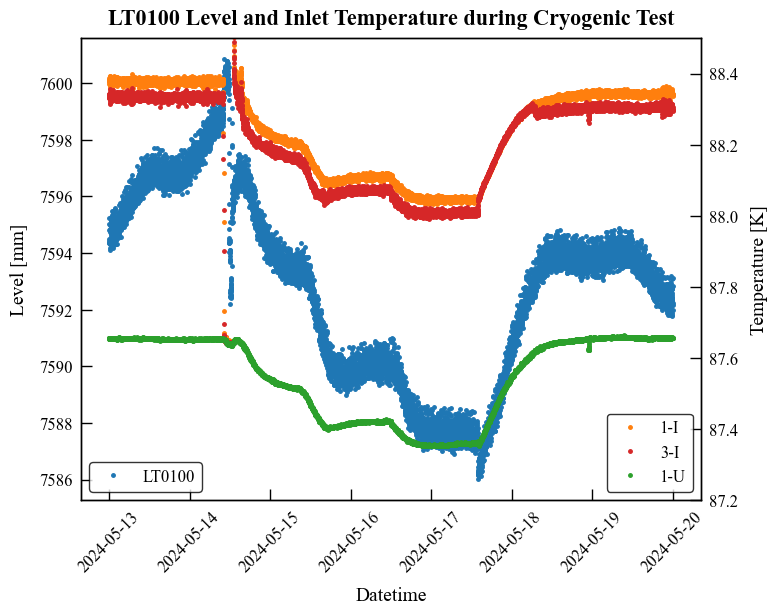

In [85]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(level1.data.index, level1.data.values, ".", label="LT0100", color="tab:blue")
axes.legend(loc="lower left")
axes.set_xlabel("Datetime")
axes.set_ylabel("Level [mm]")
axes2 = axes.twinx()
axes2.plot(pipe.sensors[49319].data.index, pipe.sensors[49319].data.values, ".", label=fr"{pipe.sensors[49319].name}", color="tab:orange")
axes2.plot(pipe.sensors[49321].data.index, pipe.sensors[49321].data.values, ".", label=fr"{pipe.sensors[49321].name}", color="tab:red")
axes2.plot(pipe.sensors[39671].data.index, pipe.sensors[39671].data.values, ".", label=fr"{pipe.sensors[39671].name}", color="tab:green")
axes2.legend(loc="lower right")
axes2.set_ylabel("Temperature [K]")
axes2.set_ylim(87.2, 88.5)
axes.set_title("LT0100 Level and Inlet Temperature during Cryogenic Test")
axes.tick_params(axis='x', rotation=45)

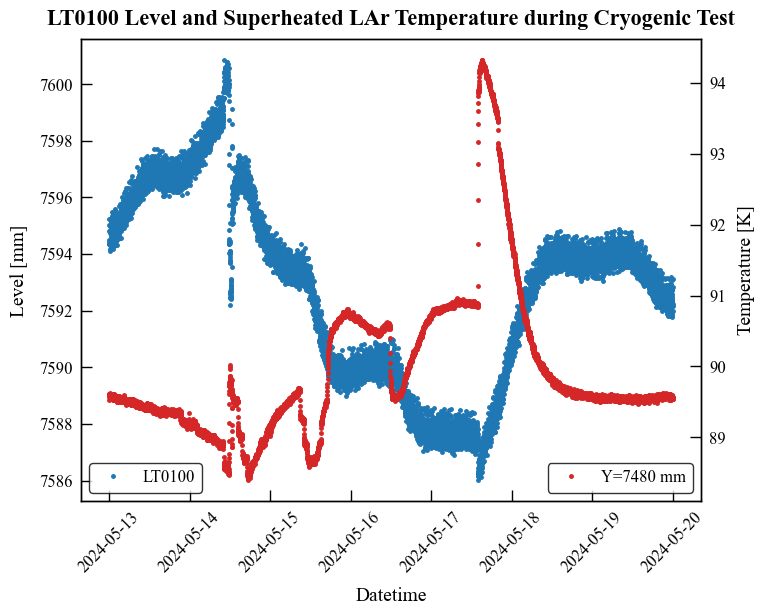

In [99]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(level1.data.index, level1.data.values, ".", label="LT0100", color="tab:blue")
axes.legend(loc="lower left")
axes.set_xlabel("Datetime")
axes.set_ylabel("Level [mm]")
axes2 = axes.twinx()
# axes2.plot(ga1.sensors[5].data.index, ga1.sensors[5].data.values, ".", label=fr"Y={ga1.sensors[5].Y:.0f} mm", color="tab:orange")
axes2.plot(hawai.sensors[40020].data.index, hawai.sensors[40020].data.values, ".", label=fr"Y={hawai.sensors[40020].Y:.0f} mm", color="tab:red")
axes2.legend(loc="lower right")
axes2.set_ylabel("Temperature [K]")
axes.set_title("LT0100 Level and Superheated LAr Temperature during Cryogenic Test")
axes.tick_params(axis='x', rotation=45)

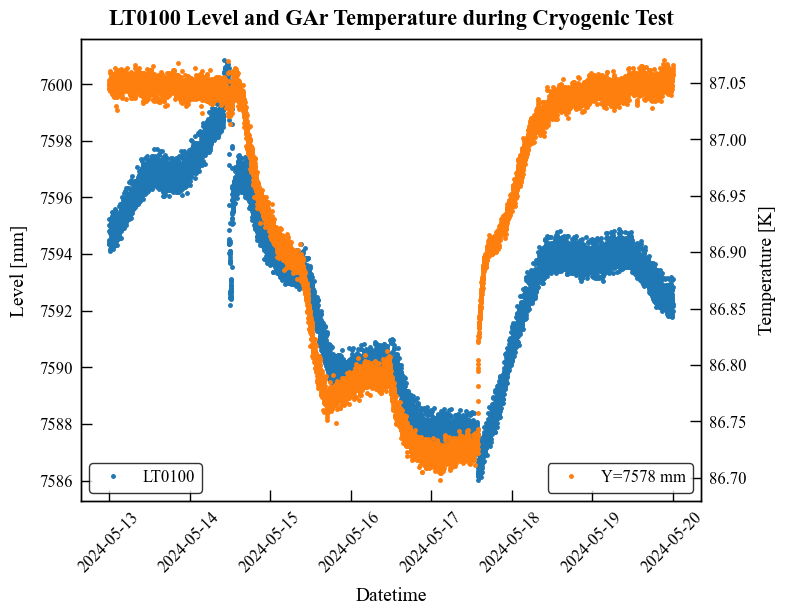

In [127]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(level1.data.index, level1.data.values, ".", label="LT0100", color="tab:blue")
axes.legend(loc="lower left")
axes.set_xlabel("Datetime")
axes.set_ylabel("Level [mm]")
axes2 = axes.twinx()
axes2.plot(ga1.sensors[4].data.index, ga1.sensors[4].data.values, ".", label=fr"Y={ga1.sensors[4].Y:.0f} mm", color="tab:orange")
axes2.legend(loc="lower right")
axes2.set_ylabel("Temperature [K]")
axes.set_title("LT0100 Level and GAr Temperature during Cryogenic Test")
axes.tick_params(axis='x', rotation=45)